In [ ]:
# This R project is essentially the same as the "python-medical-project.ipynb" performed in the R programming language.
# The following is a reminder of the project scope and purpose, with consideration for R:
# This project makes use of the dataset:
#  us_counties_covid19.csv (Kaggle: https://www.kaggle.com/datasets/sudalairajkumar/covid19-in-usa)
#  Dimensions: over 800,000 observations, across 6 variables (date, county, state, fips, cases, deaths)
#  Range of Time: January 21, 2020 - December 5, 2020

# Note: @plaintext@ represents library systems and other terminologies encased.

# The COVID-19 pandemic presented a global health crisis, with the United States being no exception.
# This dataset tracks the progress of new cases across the various states, and their particular counties.
# Do note that this dataset does not include information regarding other non-state territories such as Washington D.C., Samoa, Puerto Rico, etc.
# Analysis and comparison of a dataset such as this withion each state will not necessarily provide ample information by itself, but can be used as a supplementary material.
# Further more granular analysis within each state using datasets that provide more context is strongly advised.

# The following has been undergone in this project:
# - Utilizing @tidyverse@ to remove missing data, and using aggregation for streamlining.
# - Creating 7-day averages to ensure consistency (in the event of likely data log frequency variance), given this require time series capabilities, we will be importing @zoo@.
# - Utilizing logarithmic plots (which essentially refocus the measurement through magnitude) to visualize the overall trajectory.
# - Synthesizing a diversity of plots, including heatmaps using @ggplot2@ (which is included within tidyverse), comparing the 16 worst-hit counties.

# This dataset focuses on exploratory analysis, the following are outside scope parameters:
# - Predictive forecasting
# - Causal inference
# - Global comparison

# The environment utilized as IDE is Google Colab, a cloud service based on Jupyter Notebook.

# That will be all.



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“Removed 96 rows containing non-finite outside the scale range (`stat_align()`).”
Warning message:
“Removed 96 rows containing missing values or values outside the scale range
(`geom_line()`).”


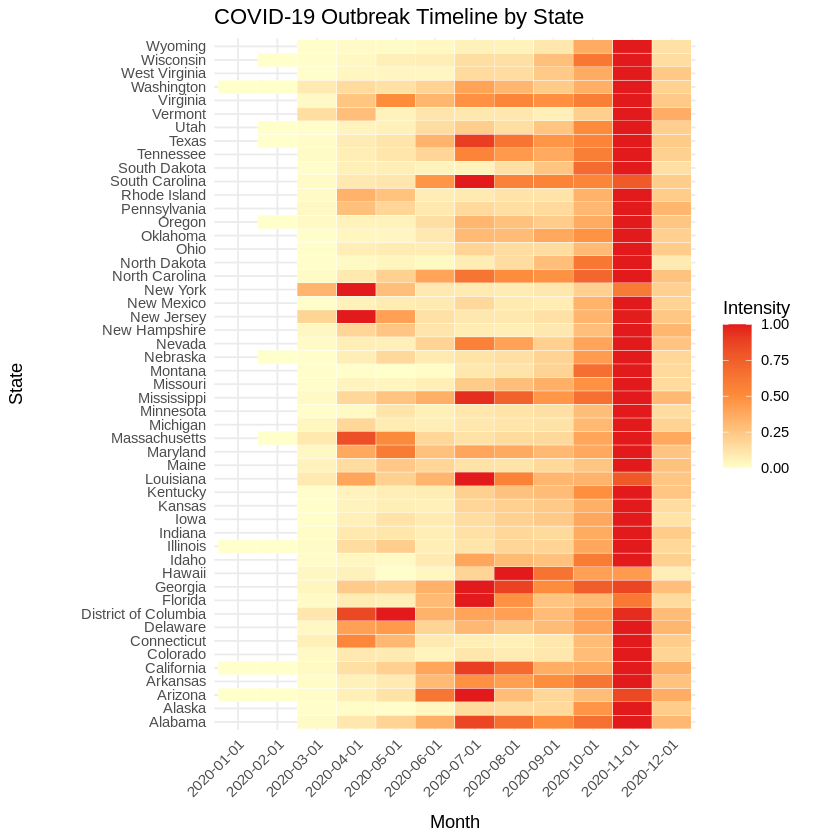

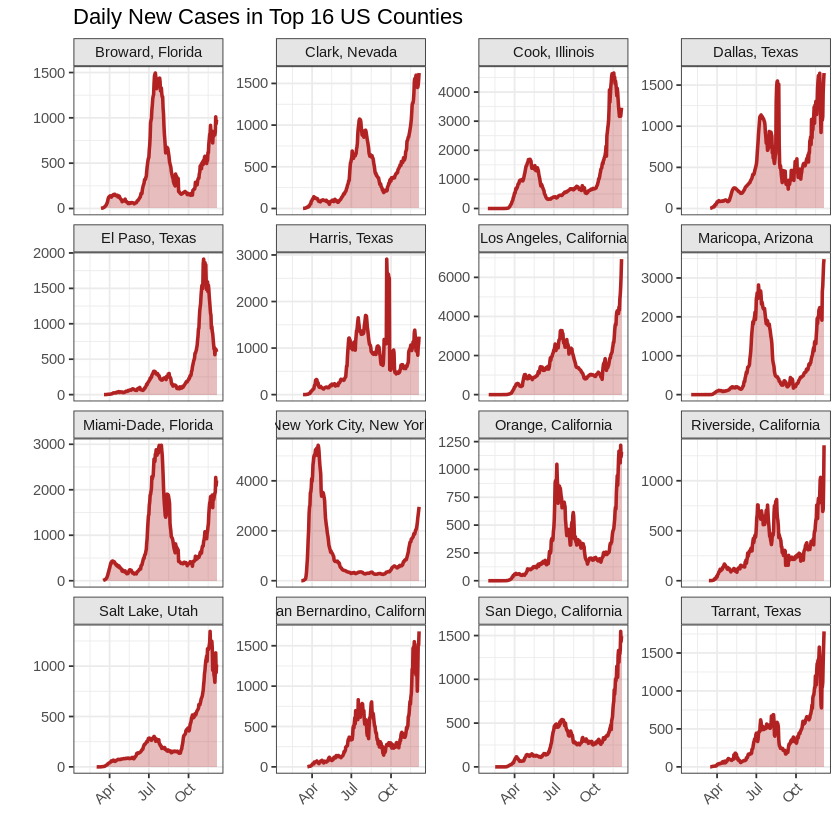

In [ ]:
# Load libraries
library(tidyverse)
install.packages("zoo")
library(zoo)

# 1. Read the CSV
df <- read_csv("us_counties_covid19_daily.csv", show_col_types = FALSE)

# STATE HEAT MAP VISUALIZATION
heatmap_data <- df %>%
  group_by(state, date) %>%
  summarise(total_cases = sum(cases), .groups = "drop") %>%
  arrange(state, date) %>%
  group_by(state) %>%
  mutate(new_cases = total_cases - lag(total_cases, default = 0)) %>%
  mutate(new_cases = ifelse(new_cases < 0, 0, new_cases)) %>%
  mutate(year_month = floor_date(date, "month")) %>%
  group_by(state, year_month) %>%
  summarise(monthly_cases = sum(new_cases), .groups = "drop") %>%
  group_by(state) %>%
  mutate(normalized_cases = monthly_cases / max(monthly_cases)) %>%
  ungroup() %>%
  filter(!state %in% c("Guam", "Northern Mariana Islands", "Virgin Islands", "Puerto Rico"))

# Plot: Heatmap of States
ggplot(heatmap_data, aes(x = as.factor(year_month), y = state, fill = normalized_cases)) +
  geom_tile(color = "white", size = 0.1) +
  scale_fill_gradientn(colors = c("#ffffcc", "#fd8d3c", "#e31a1c"), name = "Intensity") +
  theme_minimal() +
  labs(title = "COVID-19 Outbreak Timeline by State", x = "Month", y = "State") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Plot: Top 16 Counties
top_16_list <- df %>%
  filter(date == max(date)) %>%
  mutate(county_state = paste(county, state, sep = ", ")) %>%
  arrange(desc(cases)) %>%
  slice_head(n = 16) %>%
  pull(county_state)

# Filter and calculate 7-day average
facet_data <- df %>%
  mutate(county_state = paste(county, state, sep = ", ")) %>%
  filter(county_state %in% top_16_list) %>%
  arrange(county_state, date) %>%
  group_by(county_state) %>%
  mutate(
    new_cases = cases - lag(cases, default = 0),
    new_cases = ifelse(new_cases < 0, 0, new_cases),
    new_cases_7d = rollmean(new_cases, k = 7, fill = NA, align = "right")
  ) %>%
  ungroup()

# Plot Grid
ggplot(facet_data, aes(x = date, y = new_cases_7d)) +
  geom_line(color = "firebrick", size = 1) +
  geom_area(fill = "firebrick", alpha = 0.3) +
  facet_wrap(~ county_state, ncol = 4, scales = "free_y") +
  scale_x_date(date_breaks = "3 months", date_labels = "%b") +
  theme_bw() +
  labs(title = "Daily New Cases in Top 16 US Counties", x = "", y = "") +
  theme(strip.background = element_rect(fill = "grey90"),
        axis.text.x = element_text(angle = 45, hjust = 1))